In [10]:
!pip install opencv-python

In [11]:
!pip install tensorflow opencv-python matplotlib numpy scikit-learn

In [12]:
import os
import cv2
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tensorflow import keras
import tensorflow

from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Dropout, BatchNormalization, Activation

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score, f1_score 

In [13]:
import zipfile

zip_path = "ear drum-20260301T130706Z-1-001.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

In [14]:
import os
print(os.listdir("/content"))

['ear drum']


In [15]:
print(os.listdir('/content/ear drum'))

['test_data', 'train_data', 'vali_data']


In [16]:
import os
import cv2

train_path = '/content/ear drum/train_data'
test_path  = '/content/ear drum/test_data'
val_path   = '/content/ear drum/vali_data'

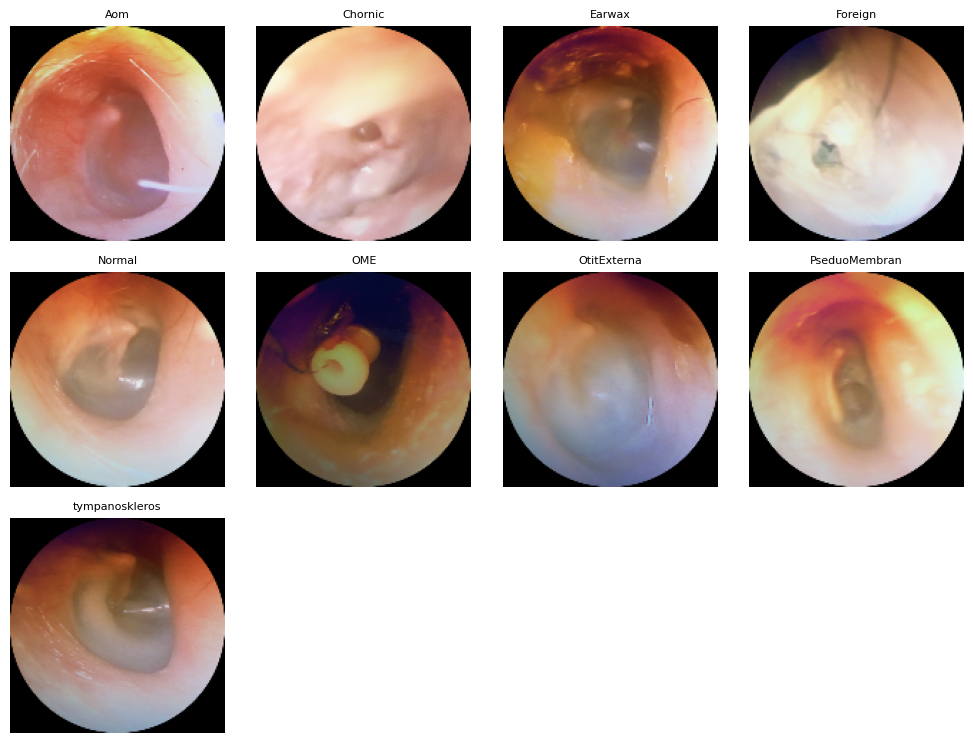

In [17]:
import os
import cv2
import matplotlib.pyplot as plt

train_path = "/content/ear drum/train_data"

#  control how many classes (folders) to display
MAX_CLASSES = 16   # change if needed

plt.figure(figsize=(10, 10))

count = 0

# loop through each folder (class)
for folder in os.listdir(train_path):

    sub_path = os.path.join(train_path, folder)

    if not os.path.isdir(sub_path):
        continue

    files = os.listdir(sub_path)
    if len(files) == 0:
        continue
    img_path = os.path.join(sub_path, files[0])

    try:
        # read image
        img = cv2.imread(img_path)

        # skip invalid images
        if img is None:
            continue

        
        img = cv2.resize(img, (150, 150))

        # convert BGR → RGB (important for matplotlib)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # plot in grid
        plt.subplot(4, 4, count + 1)
        plt.imshow(img)
        plt.title(folder, fontsize=8)
        plt.axis('off')

        count += 1

        # stop when limit reached
        if count >= MAX_CLASSES:
            break

    except Exception as e:
        print("Error loading image:", e)
        continue

# adjust layout and show
plt.tight_layout()
plt.show()

In [18]:
def imagearray(path, size):
    data = []
    
    for folder in os.listdir(path):
        sub_path = os.path.join(path, folder)
        
        if os.path.isdir(sub_path):
            for img in os.listdir(sub_path):
                image_path = os.path.join(sub_path, img)
                
                img_arr = cv2.imread(image_path)
                
                if img_arr is not None:
                    img_arr = cv2.resize(img_arr, size)
                    data.append(img_arr)
                    
    return data

In [19]:
size = (250,250)

train = imagearray(train_path, size)
test  = imagearray(test_path, size)
val   = imagearray(val_path, size)

print("Train images:", len(train))
print("Test images:", len(test))
print("Validation images:", len(val))

Train images: 829
Test images: 393
Validation images: 54


In [20]:
x_train = np.array(train)
x_test = np.array(test)
x_val = np.array(val)

In [21]:
x_train = x_train/255.0
x_test = x_test/255.0
x_val = x_val/255.0

In [22]:
def data_class(data_path, size, class_mode):
    datagen = ImageDataGenerator(rescale = 1./255)
    classes = datagen.flow_from_directory(data_path,
                                          target_size = size,
                                          batch_size = 32,
                                          class_mode = class_mode)
    return classes

In [23]:
import warnings
warnings.filterwarnings("ignore")

from tensorflow.keras.preprocessing.image import ImageDataGenerator

def data_class(path, img_size, class_mode, color_mode='rgb'):
    
    datagen = ImageDataGenerator(rescale=1./255)

    data = datagen.flow_from_directory(
        path,
        target_size=(img_size, img_size),
        class_mode=class_mode,
        color_mode='rgb',
        batch_size=32
    )

    return data


train_class = data_class(train_path, size, 'sparse')
test_class  = data_class(test_path, size, 'sparse')
val_class   = data_class(val_path, size, 'sparse')

Found 829 images belonging to 9 classes.
Found 393 images belonging to 9 classes.
Found 54 images belonging to 9 classes.


In [24]:
y_train = train_class.classes
y_test = test_class.classes
y_val = val_class.classes

In [25]:
train_class.class_indices

{'Aom': 0,
 'Chornic': 1,
 'Earwax': 2,
 'Foreign': 3,
 'Normal': 4,
 'OME': 5,
 'OtitExterna': 6,
 'PseduoMembran': 7,
 'tympanoskleros': 8}

In [26]:
y_train.shape,y_test.shape,y_val.shape

((829,), (393,), (54,))

In [27]:
vgg = VGG19(input_shape = (250, 250, 3), weights = 'imagenet', include_top = False)

In [28]:
for layer in vgg.layers:
    layer.trainable = False

x = Flatten()(vgg.output)
prediction = Dense(9, activation='softmax')(x)

model = Model(inputs=vgg.input, outputs=prediction)
model.summary()
model.compile(
  loss='sparse_categorical_crossentropy',
  optimizer="adam",
  metrics=['accuracy']
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 250, 250, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 250, 250, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 125, 125, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 125, 125, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 62, 62, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 62, 62, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 62, 62, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 62, 62, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 31, 31, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 31, 31, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 31, 31, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 31, 31, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 31, 31, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 15, 15, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │       225,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,250,185 (77.25 MB)

 Trainable params: 225,801 (882.04 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [29]:
Early_stop = EarlyStopping(monitor = 'val_loss', mode='min', verbose = 1, patience = 10)

In [30]:
VGG = model.fit(x_train, y_train, validation_data =(x_val,y_val), epochs = 20,callbacks=[Early_stop],batch_size = 30)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 242s 9s/step - accuracy: 0.5211 - loss: 2.2375 - val_accuracy: 0.2593 - val_loss: 3.5525
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 243s 9s/step - accuracy: 0.6852 - loss: 1.2302 - val_accuracy: 0.3519 - val_loss: 3.5873
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 401s 15s/step - accuracy: 0.7008 - loss: 0.9685 - val_accuracy: 0.3333 - val_loss: 2.1671
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 130s 5s/step - accuracy: 0.7612 - loss: 0.7591 - val_accuracy: 0.3333 - val_loss: 1.8351
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.7696 - loss: 0.6513 - val_accuracy: 0.4074 - val_loss: 2.3215
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 128s 5s/step - accuracy: 0.8046 - loss: 0.5963 - val_accuracy: 0.3148 - val_loss: 2.5261
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 127s 5s/step - accuracy: 0.8010 - loss: 0.5881 - val_accuracy: 0.4074 - val_loss: 1.8569
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 127s 5s/step - accuracy: 0.8347 - loss: 0.5158 - val_accuracy: 0.3889 - 

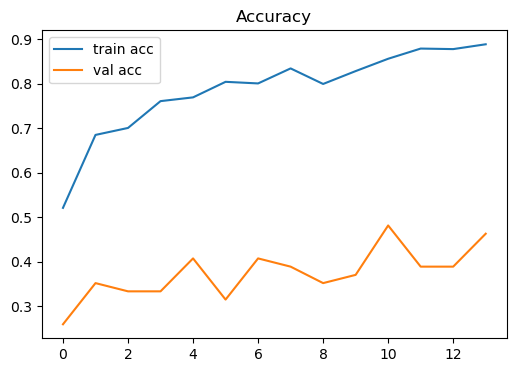

In [31]:
plt.figure(figsize=(6, 4))
plt.plot(VGG.history['accuracy'], label='train acc')
plt.plot(VGG.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')
plt.show()

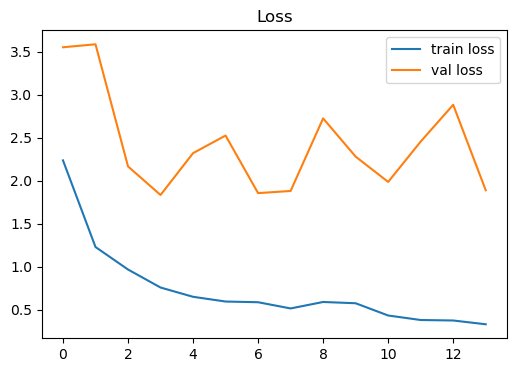

In [32]:
plt.figure(figsize=(6, 4))
plt.plot(VGG.history['loss'], label='train loss')
plt.plot(VGG.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()

In [33]:
model.evaluate(x_test, y_test, batch_size=32)

13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.9822 - loss: 0.1644


[0.16439832746982574, 0.9821882843971252]

In [34]:
y_pred = model.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 63s 5s/step


In [35]:
y_pred=np.argmax(y_pred,axis=1)

In [36]:
print(confusion_matrix(y_test,y_pred))
print('\n')

[[341   0   3   0   0]
 [  0   5   0   0   0]
 [  1   0  24   0   0]
 [  0   0   0   4   0]
 [  3   0   0   0  12]]




In [37]:
print('Accuracy : %.3f' %accuracy_score(y_test,y_pred))

result1 = round((accuracy_score(y_test,y_pred)),3)
result1

Accuracy : 0.982


0.982

In [38]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           4       0.99      0.99      0.99       345
           5       1.00      1.00      1.00         5
           6       0.96      0.89      0.92        27
           7       1.00      1.00      1.00         4
           8       0.80      1.00      0.89        12

    accuracy                           0.98       393
   macro avg       0.95      0.98      0.96       393
weighted avg       0.98      0.98      0.98       393



In [39]:
from sklearn.metrics import classification_report

# Calculate classification report including overall specificity and sensitivity
report = classification_report(y_pred,y_test, digits=4, output_dict=True)

# Extract overall specificity and sensitivity (averaged across all classes)
overall_specificity = report['macro avg']['recall']
overall_sensitivity = report['macro avg']['precision']

# Print the results
print(f"Overall Specificity: {overall_specificity:.4f}")
print(f"Overall Sensitivity: {overall_sensitivity:.4f}")

Overall Specificity: 0.9755
Overall Sensitivity: 0.9503


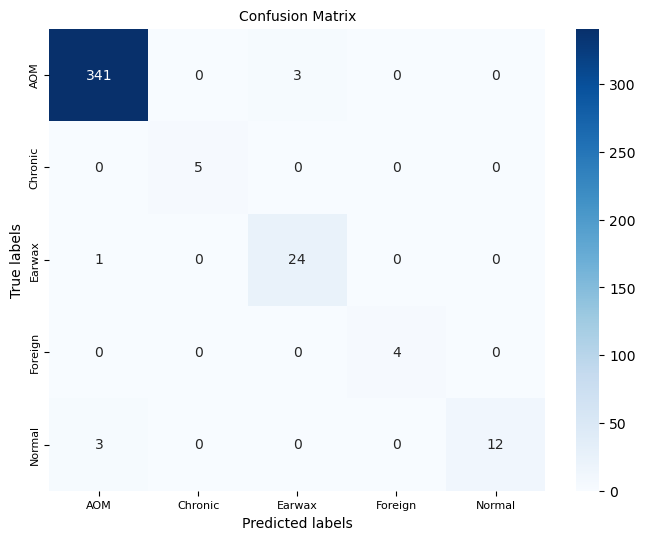

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
ax = plt.subplot()

sns.heatmap(conf_matrix,
            annot=True,
            fmt='g',
            cmap='Blues',
            ax=ax)

# labels must match number of classes
labels = ['AOM','Chronic','Earwax','Foreign','Normal']

ax.set_xlabel('Predicted labels', fontsize=10)
ax.set_ylabel('True labels', fontsize=10)
ax.set_title('Confusion Matrix', fontsize=10)

ax.set_xticklabels(labels, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

plt.show()

In [41]:
model.save("modelVGG19.keras")

In [42]:
# This just for the One type of Diagnose i have colleted the Data for it .
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [43]:
df= pd.read_csv('dataset2.csv')

In [44]:
X= df.drop(columns=['classification'], axis=1)
#X=x[:10]
y= df['classification']
#y=Y[:10]

In [45]:
X

,pressure(peak),Compilance (peak)
0,5,0.49
1,-10,0.40
2,5,0.68
3,30,0.66
4,0,0.54
5,-3,17.00
6,16,0.23
7,0,0.32
8,-35,0.39
9,125,0.25


In [46]:
y

0     A
1     A
2     A
3     A
4     A
5     C
6     C
7     C
8     C
9     C
10    C
11    c
12    C
13    A
14    A
15    A
16    A
17    A
18    A
19    A
20    A
21    A
22    A
23    A
24    A
25    A
26    A
27    A
28    A
29    A
30    A
31    A
32    A
33    A
34    A
35    A
36    A
37    A
38    A
39    A
40    A
41    A
42    B
43    B
44    B
45    B
46    B
47    C
48    C
49    B
50    B
51    A
52    A
53    B
54    B
55    A
56    A
57    B
Name: classification, dtype: object

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [48]:
rf= RandomForestClassifier(criterion='gini',n_estimators=30,random_state=25,n_jobs=5)

In [49]:
rf.fit(X_train,y_train)

prediction= rf.predict(X_test)
print('Accuracy : %.3f' %accuracy_score(y_test,prediction))

result2 = round(accuracy_score(y_test,prediction),3)
result2

Accuracy : 0.917


0.917

In [50]:
print(confusion_matrix(y_test,prediction))
print('\n')


[[8 0 1]
 [0 2 0]
 [0 0 1]]




In [51]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           A       1.00      0.89      0.94         9
           B       1.00      1.00      1.00         2
           C       0.50      1.00      0.67         1

    accuracy                           0.92        12
   macro avg       0.83      0.96      0.87        12
weighted avg       0.96      0.92      0.93        12



In [52]:
from sklearn.metrics import classification_report

# Calculate classification report including overall specificity and sensitivity
report = classification_report(y_test,prediction, digits=4, output_dict=True)

# Extract overall specificity and sensitivity (averaged across all classes)
overall_specificity = report['macro avg']['recall']
overall_sensitivity = report['macro avg']['precision']

# Print the results
print(f"Overall Specificity: {overall_specificity:.4f}")
print(f"Overall Sensitivity: {overall_sensitivity:.4f}")

Overall Specificity: 0.9630
Overall Sensitivity: 0.8333


In [53]:
def simple_average(results):
    n = len(results)
    fused_result = sum(results) / n
    return fused_result


In [54]:
results = [result1,result2]
fused_result = simple_average(results)
print(fused_result)

0.9495


In [60]:
# Run this first to see your real class names before editing class_mapping
print("VGG19 class order:", train_class.class_indices)
print("RF    class order:", rf.classes_)
class_mapping = {
    'AOM':    'AOM',
    'Normal': 'Normal',
    # ... and so on
}

VGG19 class order: {'Aom': 0, 'Chornic': 1, 'Earwax': 2, 'Foreign': 3, 'Normal': 4, 'OME': 5, 'OtitExterna': 6, 'PseduoMembran': 7, 'tympanoskleros': 8}
RF    class order: ['A' 'B' 'C' 'c']


In [64]:
# ============================================================
# FULLY FIXED FUSION — y_test is string labels
# ============================================================

prob_vgg    = model.predict(x_test)      # (393, 9)
prob_rf_raw = rf.predict_proba(X_test)   # (58, 4)

vgg_classes = list(train_class.class_indices.keys())  # 9 VGG class names
rf_classes  = list(rf.classes_)                       # ['A','B','C','c']

print("VGG classes:", vgg_classes)
print("RF  classes:", rf_classes)
print("y_test sample:", y_test[:5].tolist())   # see what's inside

# --- Check your CSV to find the real disease for each letter ---
# Run this once, then fill the mapping below
df2 = pd.read_csv('dataset2.csv')
print("\nCSV classification unique values:", df2['classification'].unique())

13/13 ━━━━━━━━━━━━━━━━━━━━ 54s 4s/step
VGG classes: ['Aom', 'Chornic', 'Earwax', 'Foreign', 'Normal', 'OME', 'OtitExterna', 'PseduoMembran', 'tympanoskleros']
RF  classes: ['A', 'B', 'C', 'c']
y_test sample: ['C', 'A', 'A', 'B', 'A']

CSV classification unique values: ['A' 'C' 'c' 'B']


In [65]:
# ============================================================
# AFTER checking CSV values, fill this mapping and run
# ============================================================

# y_test here is the RF y_test (string labels like 'A','B','C','c')
# We need to convert RF string labels → VGG integer indices

# EDIT: map each RF letter to matching VGG class name
rf_to_vgg = {
    'A': 'Aom',        # ← replace right side with actual disease name
    'B': 'Normal',     # ← replace
    'C': 'Earwax',     # ← replace
    'c': 'Foreign',    # ← replace (note lowercase c)
}

# Convert RF string labels → VGG integer index
def rf_label_to_vgg_idx(label):
    vgg_name = rf_to_vgg.get(label, None)
    if vgg_name and vgg_name in vgg_classes:
        return vgg_classes.index(vgg_name)
    return -1   # -1 means unmapped — check your rf_to_vgg dict

# Build aligned RF probability matrix (58, 9)
prob_rf_aligned = np.zeros((len(prob_rf_raw), len(vgg_classes)))
for rf_cls, vgg_cls in rf_to_vgg.items():
    if rf_cls in rf_classes and vgg_cls in vgg_classes:
        rf_col  = rf_classes.index(rf_cls)
        vgg_col = vgg_classes.index(vgg_cls)
        prob_rf_aligned[:, vgg_col] = prob_rf_raw[:, rf_col]
        print(f"  Mapped RF['{rf_cls}'] → VGG['{vgg_cls}'] (col {vgg_col})")

# Convert y_test (RF string labels) → integer indices for evaluation
y_test_idx = np.array([rf_label_to_vgg_idx(lbl) for lbl in y_test])
print("\ny_test_idx sample:", y_test_idx[:10])
print("Any unmapped (-1)?", (y_test_idx == -1).sum())  # must be 0!

# Subset VGG to match RF test size (58 samples)
prob_vgg_subset = prob_vgg[:len(prob_rf_raw)]      # (58, 9)
y_test_subset   = y_test_idx[:len(prob_rf_raw)]    # (58,) integers

# Average probabilities
avg_prob       = (prob_vgg_subset + prob_rf_aligned) / 2.0
fused_pred_avg = np.argmax(avg_prob, axis=1)

# Individual predictions
vgg_pred_subset = np.argmax(prob_vgg_subset, axis=1)
rf_pred_subset  = np.argmax(prob_rf_aligned, axis=1)

# Evaluate — all integer labels now, no type mismatch
print("\n=== SCORE-LEVEL FUSION RESULTS ===")
print(f"VGG19 alone : {accuracy_score(y_test_subset, vgg_pred_subset):.4f}")
print(f"RF alone    : {accuracy_score(y_test_subset, rf_pred_subset):.4f}")
print(f"Fused       : {accuracy_score(y_test_subset, fused_pred_avg):.4f}")
print()
print(classification_report(
    y_test_subset,
    fused_pred_avg,
    labels=list(range(len(vgg_classes))),
    target_names=vgg_classes
))

  Mapped RF['A'] → VGG['Aom'] (col 0)
  Mapped RF['B'] → VGG['Normal'] (col 4)
  Mapped RF['C'] → VGG['Earwax'] (col 2)
  Mapped RF['c'] → VGG['Foreign'] (col 3)

y_test_idx sample: [2 0 0 4 0 0 0 0 0 0]
Any unmapped (-1)? 0

=== SCORE-LEVEL FUSION RESULTS ===
VGG19 alone : 0.1667
RF alone    : 0.9167
Fused       : 0.8333

                precision    recall  f1-score   support

           Aom       1.00      0.89      0.94         9
       Chornic       0.00      0.00      0.00         0
        Earwax       0.00      0.00      0.00         1
       Foreign       0.00      0.00      0.00         0
        Normal       0.67      1.00      0.80         2
           OME       0.00      0.00      0.00         0
   OtitExterna       0.00      0.00      0.00         0
 PseduoMembran       0.00      0.00      0.00         0
tympanoskleros       0.00      0.00      0.00         0

      accuracy                           0.83        12
     macro avg       0.19      0.21      0.19        12
 

                 Method  Accuracy
            VGG19 Alone    0.1667
    Random Forest Alone    0.9167
Score Fusion (Avg Prob)    0.8333
Score Fusion (Weighted)    0.8333


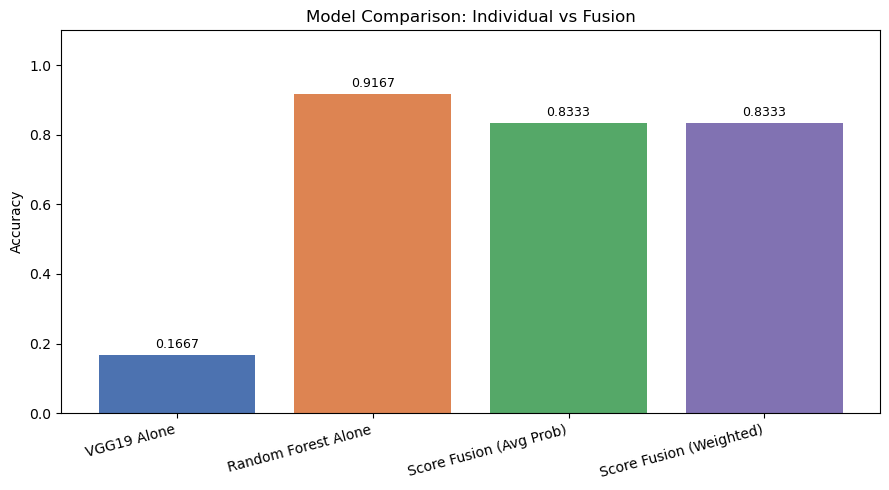

Done! Chart saved as fusion_comparison.png


In [67]:
# ============================================================
# COMPARISON TABLE — FIXED
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

# All evaluations use y_test_subset (58 samples, integer indices)
# which is aligned between both models

acc_vgg    = accuracy_score(y_test_subset, vgg_pred_subset)
acc_rf     = accuracy_score(y_test_subset, rf_pred_subset)
acc_fused  = accuracy_score(y_test_subset, fused_pred_avg)

# Weighted fusion
w_vgg = acc_vgg / (acc_vgg + acc_rf)
w_rf  = acc_rf  / (acc_vgg + acc_rf)
weighted_prob        = (w_vgg * prob_vgg_subset) + (w_rf * prob_rf_aligned)
fused_pred_weighted  = np.argmax(weighted_prob, axis=1)
acc_weighted         = accuracy_score(y_test_subset, fused_pred_weighted)

comparison = pd.DataFrame({
    'Method': [
        'VGG19 Alone',
        'Random Forest Alone',
        'Score Fusion (Avg Prob)',
        'Score Fusion (Weighted)'
    ],
    'Accuracy': [
        round(acc_vgg,   4),
        round(acc_rf,    4),
        round(acc_fused, 4),
        round(acc_weighted, 4)
    ]
})

print(comparison.to_string(index=False))

# Bar chart
plt.figure(figsize=(9, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#8172B2']
plt.bar(comparison['Method'], comparison['Accuracy'], color=colors)
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Model Comparison: Individual vs Fusion')
plt.xticks(rotation=15, ha='right')
for i, val in enumerate(comparison['Accuracy']):
    plt.text(i, val + 0.02, f'{val:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fusion_comparison.png', dpi=150)
plt.show()
print("Done! Chart saved as fusion_comparison.png")